# CC3092 - Laboratorio 7 - Task 4

Analisis comparativo: ACF vs atencion (4.1) y LSTM vs Transformer vs naive (4.2). Este notebook usa los resultados guardados en `results/` por `Lab7_Task2.ipynb` y `Lab7_Task3.ipynb`; ejecutelos antes.

## Setup (reproduce el Task 1)

Este notebook es autocontenido: se repite el pipeline de `Lab7_Task1.ipynb` (normalizacion z-score de `OT`, split temporal 60/20/20 y ventanas con $L=96$, $H\in\{24,48\}$). La explicacion detallada de cada paso esta en el notebook del Task 1.

In [1]:
import json
import math
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
DATA_PATH = Path("ETTh1.csv")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    urllib.request.urlretrieve(URL, DATA_PATH)

In [2]:
data = np.genfromtxt(DATA_PATH, delimiter=",", skip_header=1)
OT = data[:, -1].astype(np.float32)       # Variable objetivo: Oil Temperature
ALL = data[:, 1:].astype(np.float32)      # Las 7 variables numericas

# z-score: x_norm = (x - mu) / sigma  (mu y sigma se guardan para desnormalizar)
mu = OT.mean()
sigma = OT.std()
OT_norm = (OT - mu) / sigma

# Split temporal contiguo: [train 60% | val 20% | test 20%], sin mezclar.
N_total = len(OT_norm)
n_train = int(0.60 * N_total)
n_val = int(0.20 * N_total)
OT_train = torch.from_numpy(OT_norm[:n_train].copy())
OT_val = torch.from_numpy(OT_norm[n_train:n_train + n_val].copy())
OT_test = torch.from_numpy(OT_norm[n_train + n_val:].copy())


def make_windows(series, L, H):
    # X^(t) = (x_{t-L+1}, ..., x_t),  y^(t) = x_{t+H}
    series = torch.as_tensor(series, dtype=torch.float32).flatten()
    n_examples = series.numel() - L - H + 1
    X = series.unfold(dimension=0, size=L, step=1)[:n_examples].clone()
    start_y = L + H - 1
    y = series[start_y:start_y + n_examples].clone()
    return X, y


L = 96
X_tr_24, y_tr_24 = make_windows(OT_train, L=L, H=24)
X_vl_24, y_vl_24 = make_windows(OT_val,   L=L, H=24)
X_ts_24, y_ts_24 = make_windows(OT_test,  L=L, H=24)
X_tr_48, y_tr_48 = make_windows(OT_train, L=L, H=48)
X_vl_48, y_vl_48 = make_windows(OT_val,   L=L, H=48)
X_ts_48, y_ts_48 = make_windows(OT_test,  L=L, H=48)

# Baseline naive: y_hat = x_t (ultimo valor observado de la ventana)
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
naive_mae_48 = torch.abs(y_vl_48 - X_vl_48[:, -1]).mean().item()

print(f"mu={mu:.4f}, sigma={sigma:.4f}")
print(f"train H=24: {tuple(X_tr_24.shape)}, val H=24: {tuple(X_vl_24.shape)}")
print(f"Naive MAE val: H=24 -> {naive_mae:.4f}, H=48 -> {naive_mae_48:.4f}")

mu=13.3247, sigma=8.5667
train H=24: (10333, 96), val H=24: (3365, 96)
Naive MAE val: H=24 -> 0.1996, H=48 -> 0.2604


In [3]:
def acf_manual(series, max_lag):
    # rho(k) = [1/(N-k) * sum_{t=k}^{N-1} (x_t - x_bar)(x_{t-k} - x_bar)] / [1/N * sum_t (x_t - x_bar)^2]
    x = np.asarray(series, dtype=np.float64).reshape(-1)
    N = x.size
    centered = x - x.mean()
    denominator = np.sum(centered ** 2) / N
    rho = np.empty(max_lag + 1, dtype=np.float64)
    for k in range(max_lag + 1):
        rho[k] = (np.sum(centered[k:] * centered[:N - k]) / (N - k)) / denominator
    return rho


acf_values = acf_manual(OT_train.numpy(), max_lag=L)

with open(RESULTS_DIR / "lstm_metrics.json") as fh:
    lstm_metrics = json.load(fh)
with open(RESULTS_DIR / "transformer_metrics.json") as fh:
    transformer_metrics = json.load(fh)
cls_attn_by_lag = {H: np.load(RESULTS_DIR / f"cls_attention_{H}.npy") for H in (24, 48)}
print("Resultados de Task 2 y Task 3 cargados")

Resultados de Task 2 y Task 3 cargados


## Task 4.1 - ACF vs atencion desde CLS

Ambas curvas se indexan por lag $k=1,\dots,96$ (lag 1 = valor mas reciente de la ventana).

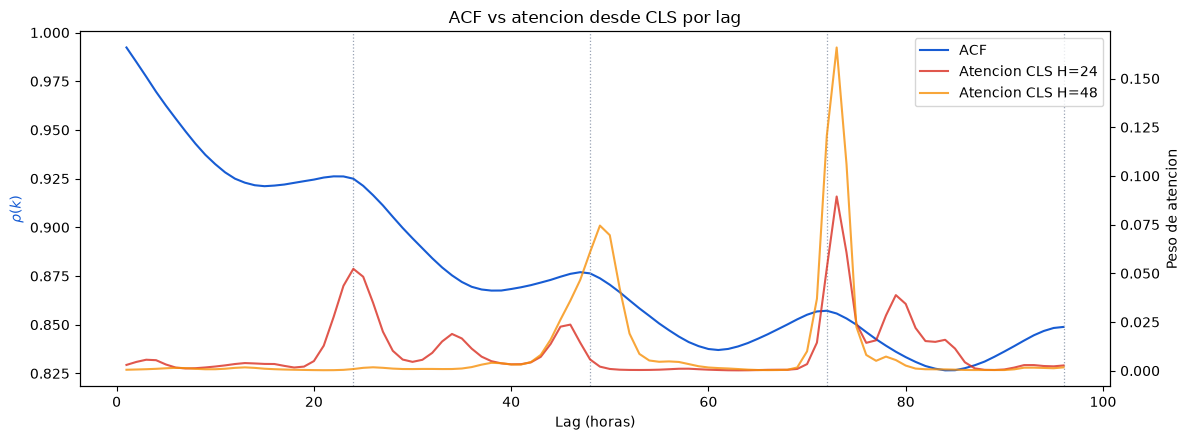

In [4]:
lags_axis = np.arange(1, L + 1)
acf_by_lag = acf_values[1:]            # rho(1), ..., rho(96)

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(lags_axis, acf_by_lag, color="#175CD3", label="ACF")
ax1.set_xlabel("Lag (horas)")
ax1.set_ylabel(r"$\rho(k)$", color="#175CD3")
ax2 = ax1.twinx()
ax2.plot(lags_axis, cls_attn_by_lag[24], color="#D92D20", alpha=0.8, label="Atencion CLS H=24")
ax2.plot(lags_axis, cls_attn_by_lag[48], color="#F79009", alpha=0.8, label="Atencion CLS H=48")
ax2.set_ylabel("Peso de atencion")
for daily_lag in (24, 48, 72, 96):
    ax1.axvline(daily_lag, color="#98A2B3", linestyle=":", linewidth=0.9)
lines = ax1.get_lines()[:1] + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="upper right")
ax1.set_title("ACF vs atencion desde CLS por lag")
plt.tight_layout()
plt.show()

In [5]:
TOP_K = 10


def local_peaks(values):
    # lags k (1-indexados) que son maximos locales
    return [k + 1 for k in range(1, len(values) - 1)
            if values[k] >= values[k - 1] and values[k] >= values[k + 1]]


print("Picos locales de la ACF (lag, rho):")
for k in local_peaks(acf_by_lag):
    print(f"  lag {k:>2}: {acf_by_lag[k - 1]:.4f}")

for H in (24, 48):
    attn = cls_attn_by_lag[H]
    top_attn = np.argsort(attn)[::-1][:TOP_K] + 1
    print(f"\nH={H}: top {TOP_K} lags por atencion vs su ACF")
    print(f"  {'lag':>4} | {'atencion':>9} | {'ACF':>7}")
    for k in top_attn:
        print(f"  {k:>4} | {attn[k - 1]:>9.5f} | {acf_by_lag[k - 1]:>7.4f}")

Picos locales de la ACF (lag, rho):
  lag 22: 0.9262
  lag 47: 0.8770
  lag 72: 0.8572

H=24: top 10 lags por atencion vs su ACF
   lag |  atencion |     ACF
    73 |   0.08942 |  0.8557
    74 |   0.06057 |  0.8532
    72 |   0.05253 |  0.8572
    24 |   0.05229 |  0.9250
    25 |   0.04823 |  0.9213
    23 |   0.04357 |  0.9261
    79 |   0.03880 |  0.8361
    26 |   0.03487 |  0.9165
    80 |   0.03427 |  0.8334
    78 |   0.02836 |  0.8392

H=48: top 10 lags por atencion vs su ACF
   lag |  atencion |     ACF
    73 |   0.16593 |  0.8557
    72 |   0.12058 |  0.8572
    74 |   0.10593 |  0.8532
    49 |   0.07448 |  0.8738
    50 |   0.06956 |  0.8705
    48 |   0.06085 |  0.8763
    47 |   0.04658 |  0.8770
    51 |   0.04237 |  0.8667
    71 |   0.03692 |  0.8568
    46 |   0.03594 |  0.8761


In [6]:
# Tabla completa por lag (util para citar valores en las respuestas)
print(f"{'lag':>4} | {'ACF':>7} | {'attn H=24':>10} | {'attn H=48':>10}")
for k in lags_axis:
    print(f"{k:>4} | {acf_by_lag[k - 1]:>7.4f} | {cls_attn_by_lag[24][k - 1]:>10.5f} | "
          f"{cls_attn_by_lag[48][k - 1]:>10.5f}")

 lag |     ACF |  attn H=24 |  attn H=48
   1 |  0.9923 |    0.00295 |    0.00047
   2 |  0.9849 |    0.00449 |    0.00060
   3 |  0.9773 |    0.00562 |    0.00075
   4 |  0.9696 |    0.00539 |    0.00095
   5 |  0.9625 |    0.00317 |    0.00123
   6 |  0.9558 |    0.00159 |    0.00145
   7 |  0.9492 |    0.00114 |    0.00131
   8 |  0.9429 |    0.00126 |    0.00095
   9 |  0.9372 |    0.00165 |    0.00073
  10 |  0.9324 |    0.00213 |    0.00074
  11 |  0.9282 |    0.00272 |    0.00099
  12 |  0.9250 |    0.00341 |    0.00144
  13 |  0.9229 |    0.00391 |    0.00170
  14 |  0.9216 |    0.00371 |    0.00143
  15 |  0.9211 |    0.00346 |    0.00101
  16 |  0.9214 |    0.00342 |    0.00075
  17 |  0.9220 |    0.00246 |    0.00059
  18 |  0.9228 |    0.00162 |    0.00047
  19 |  0.9237 |    0.00209 |    0.00038
  20 |  0.9245 |    0.00491 |    0.00029
  21 |  0.9256 |    0.01283 |    0.00024
  22 |  0.9262 |    0.02754 |    0.00026
  23 |  0.9261 |    0.04357 |    0.00042
  24 |  0.9250 |

### 4.1a - ¿Coinciden los lags con mayor atención con los picos de la ACF?

**Respuesta:** **Coinciden en parte.** Los dos detectan el ciclo diario de la temperatura, pero no le dan importancia a los mismos momentos.

| Lag (horas atrás) | ACF | Atención $H=24$ | Atención $H=48$ |
|---|---|---|---|
| 1 | **0.992** | 0.003 | 0.001 |
| 2 | **0.985** | 0.004 | 0.001 |
| 24 | 0.925 | **0.052** | 0.001 |
| 48 | 0.876 | 0.006 | **0.061** |
| 72 | 0.857 | **0.053** | **0.121** |
| 73 | 0.856 | **0.089** | **0.166** |

*(Como referencia, si la atención se repartiera por igual, cada lag recibiría 0.010.)*

**En qué coinciden.** La ACF tiene picos cerca de las 22, 47 y 72 horas, es decir, cada ~24 h. La atención también se concentra alrededor de múltiplos de 24 (lags 23-25, 47-50 y 72-74). Los dos métodos "descubren" lo mismo: la temperatura del aceite sigue un ciclo diario.

**En qué no coinciden.**
- **Lo más reciente:** para la ACF, los lags más importantes son los más recientes (1 y 2 horas atrás, con correlación de 0.99). El Transformer casi no los mira: reciben menos atención que si la repartiera por igual.
- **El orden entre días:** la ACF baja poco a poco con la distancia (hace 1 día > hace 2 días > hace 3 días). El Transformer, en cambio, prefiere el valor de **hace 3 días** (lag 72-73) sobre el de hace 1 día.

**Hipótesis de por qué el Transformer aprendió algo distinto:**
1. **Lo reciente ya lo tiene "gratis".** El modelo no predice la temperatura directamente, sino **cuánto va a cambiar** respecto al último valor, que después se suma. La información de la última hora ya está incluida en la predicción, así que mirarla otra vez no aporta nada. Lo útil para predecir el *cambio* es qué pasó a esa misma hora en días anteriores.
2. **La ACF y el modelo responden preguntas distintas.** La ACF mide cuánto se parece el valor de *ahora* a los del pasado. El modelo necesita predecir el valor de *dentro de 24 o 48 horas*. Ese momento futuro cae a la misma hora del día que hace 24, 48 y 72 horas, y justo ahí mira el modelo.
3. **No necesita mirar todo lo que se parece.** Las horas vecinas son casi iguales entre sí, así que la ACF de todas es alta. La atención funciona como una selección: con elegir unos pocos momentos representativos le basta, en lugar de repartir peso entre muchos lags que dicen lo mismo.
4. **El ciclo no es exacto.** El pico de la ACF está en 22 h y no en 24, y la atención cae en 73 y no en 72. El ciclo diario real no dura exactamente 24 horas, y además estos mapas son el promedio de solo 5 ejemplos.

### 4.1b - Dependencias no lineales que captura la atención y la ACF no

**Respuesta:** La ACF da **un solo número por lag para toda la serie**: por ejemplo, "en promedio, el valor de hace 24 horas se parece en 0.925 al actual". Ese número es fijo, es un promedio de todos los días y solo compara pares de valores con una relación en línea recta.

La atención, en cambio, **decide a qué momentos mirar en cada ventana según lo que ve en ella**. Por eso puede captar relaciones que la ACF no detecta:

- **Dependencias que cambian según la situación.** Tal vez el valor de hace 24 horas importa mucho cuando la temperatura viene subiendo y poco cuando está estable; o se comporta distinto en fin de semana o en verano. La ACF mezcla todos esos casos en un solo promedio.
- **Combinaciones de varios momentos.** Por ejemplo, "si subió rápido en las últimas horas **y** ayer a esta hora hubo un pico, entonces…". La ACF solo compara dos momentos a la vez.
- **Relaciones que no son en línea recta.** Efectos de umbral (a partir de cierta temperatura se activa el enfriamiento) o de saturación. La correlación lineal puede ser baja aunque la relación sea muy útil para predecir.
- **Búsqueda de patrones parecidos.** La atención puede ir a un momento del pasado que se parezca a la situación actual, aunque ese lag tenga una ACF baja.

**¿Hay evidencia en nuestros mapas?**
1. **Sí: el patrón cambia según lo que se quiere predecir.** La ACF es una sola para la serie, pero la atención es distinta en los dos modelos. Con $H=24$ mira las horas 23-26 y 72-74 atrás; con $H=48$ se mueve a 46-51 y 72-74. El Transformer adapta a dónde mira según el objetivo, algo que la ACF no puede hacer.
2. **Sí: da peso a momentos que la ACF considera menos importantes.** Los lags 78-80 (ACF de 0.83) reciben más atención que los lags 1-3 (ACF de 0.98). Lo que el modelo considera útil no sigue el orden de la ACF.
3. **Limitación:** analizamos el **promedio** de 5 ejemplos. Para demostrar que la atención cambia de una ventana a otra según su contenido habría que comparar los mapas ejemplo por ejemplo. Con el promedio podemos afirmar que el patrón aprendido es distinto al de la ACF, pero no probar del todo que dependa de cada situación.

## Task 4.2 - Comparacion LSTM vs Transformer

In [7]:
# Baseline naive: y_hat = x_t
naive_metrics = {}
for H, X_vl, y_vl, ref in [(24, X_vl_24, y_vl_24, naive_mae), (48, X_vl_48, y_vl_48, naive_mae_48)]:
    err = y_vl - X_vl[:, -1]
    naive_metrics[str(H)] = {
        "mae": err.abs().mean().item(),
        "rmse": torch.sqrt((err ** 2).mean()).item(),
        "ratio": 1.0,
    }

rows = []
for name, m in [("LSTM", lstm_metrics), ("Transformer", transformer_metrics), ("Naive", naive_metrics)]:
    for H in ("24", "48"):
        rows.append((name, f"{H}h", m[H]["mae"], m[H]["rmse"], m[H]["ratio"]))

print("Metricas en validacion (escala normalizada)\n")
print(f"| {'Modelo':<11} | {'Horizonte':<9} | {'MAE':>7} | {'RMSE':>7} | {'Ratio vs naive':>14} |")
print(f"|{'-'*13}|{'-'*11}|{'-'*9}|{'-'*9}|{'-'*16}|")
for name, H, mae, rmse, ratio in rows:
    print(f"| {name:<11} | {H:<9} | {mae:>7.4f} | {rmse:>7.4f} | {ratio:>14.3f} |")

Metricas en validacion (escala normalizada)

| Modelo      | Horizonte |     MAE |    RMSE | Ratio vs naive |
|-------------|-----------|---------|---------|----------------|
| LSTM        | 24h       |  0.1959 |  0.2602 |          0.982 |
| LSTM        | 48h       |  0.2389 |  0.3096 |          0.918 |
| Transformer | 24h       |  0.1933 |  0.2510 |          0.968 |
| Transformer | 48h       |  0.2475 |  0.3070 |          0.950 |
| Naive       | 24h       |  0.1996 |  0.2672 |          1.000 |
| Naive       | 48h       |  0.2604 |  0.3359 |          1.000 |


## Experimento con mas semillas

La tabla anterior compara **una sola corrida** por modelo, y las diferencias entre LSTM y Transformer son de 1-4% en MAE. Para saber si esas diferencias son reales o dependen de la semilla (inicializacion de pesos y orden de los mini-batches), se repitio el entrenamiento con 6 semillas: 0, 1, 2, 3, 4 y 42.

- **Misma configuracion** que los Tasks 2 y 3: arquitecturas, 20 epocas, Adam, `batch_size=64`, MSE y prediccion residual.
- **Reproducible:** cada entrenamiento fija el numero de hilos y usa `torch.use_deterministic_algorithms(True)`. Asi, correr el experimento otra vez da exactamente los mismos numeros.
- **No modifica** el pipeline principal ni las celdas de verificacion de los Tasks 2 y 3.
- **Se entrena desde un script:** `experimento_semillas.py` corre los 24 entrenamientos en paralelo y guarda `results/semillas.json`. En Windows, Jupyter no puede lanzar procesos en paralelo con funciones definidas dentro del notebook. Por defecto esta celda solo carga los resultados; con `RUN_EXPERIMENT = True` vuelve a entrenar todo (~25 min con 6 procesos).

In [8]:
import subprocess
import sys

RUN_EXPERIMENT = False   # True = reentrenar las 24 combinaciones (modelo x horizonte x semilla)
SEEDS_PATH = RESULTS_DIR / "semillas.json"

if RUN_EXPERIMENT or not SEEDS_PATH.exists():
    subprocess.run([sys.executable, "experimento_semillas.py"], check=True)

with open(SEEDS_PATH) as fh:
    seed_exp = json.load(fh)
seeds = seed_exp["seeds"]
seed_res = {(r["model"], r["H"], r["seed"]): r for r in seed_exp["results"]}

# Media y desviacion estandar (muestral) sobre las semillas
print(f"Semillas: {seeds}\n")
print(f"| {'Modelo':<11} | {'H':<3} | {'MAE media ± std':>17} | {'RMSE media ± std':>17} | {'Ratio media ± std':>17} |")
print(f"|{'-'*13}|{'-'*5}|{'-'*19}|{'-'*19}|{'-'*19}|")
for model_name in ("LSTM", "Transformer"):
    for H in (24, 48):
        mae = np.array([seed_res[(model_name, H, s)]["mae"] for s in seeds])
        rmse = np.array([seed_res[(model_name, H, s)]["rmse"] for s in seeds])
        ratio = np.array([seed_res[(model_name, H, s)]["ratio"] for s in seeds])
        print(f"| {model_name:<11} | {H:<3} | {mae.mean():.4f} ± {mae.std(ddof=1):.4f} | "
              f"{rmse.mean():.4f} ± {rmse.std(ddof=1):.4f} | {ratio.mean():.3f} ± {ratio.std(ddof=1):.3f} |")

Semillas: [0, 1, 2, 3, 4, 42]

| Modelo      | H   |   MAE media ± std |  RMSE media ± std | Ratio media ± std |
|-------------|-----|-------------------|-------------------|-------------------|
| LSTM        | 24  | 0.1986 ± 0.0044 | 0.2594 ± 0.0033 | 0.995 ± 0.022 |
| LSTM        | 48  | 0.2515 ± 0.0027 | 0.3202 ± 0.0055 | 0.966 ± 0.010 |
| Transformer | 24  | 0.1954 ± 0.0049 | 0.2519 ± 0.0021 | 0.979 ± 0.025 |
| Transformer | 48  | 0.2429 ± 0.0044 | 0.3056 ± 0.0024 | 0.933 ± 0.017 |


semilla |  LSTM 24   Trf 24      dif |  LSTM 48   Trf 48      dif
      0 |   0.2053   0.1932  -0.0121 |   0.2489   0.2445  -0.0045
      1 |   0.1953   0.1911  -0.0042 |   0.2489   0.2375  -0.0114
      2 |   0.1943   0.2051  +0.0107 |   0.2499   0.2429  -0.0070
      3 |   0.2006   0.1937  -0.0069 |   0.2545   0.2472  -0.0073
      4 |   0.1950   0.1956  +0.0006 |   0.2550   0.2379  -0.0171
     42 |   0.2012   0.1938  -0.0074 |   0.2516   0.2475  -0.0041

H=24: Transformer gana en 4/6 semillas; diferencia media = -0.0032 (std 0.0080)

H=48: Transformer gana en 6/6 semillas; diferencia media = -0.0086 (std 0.0049)


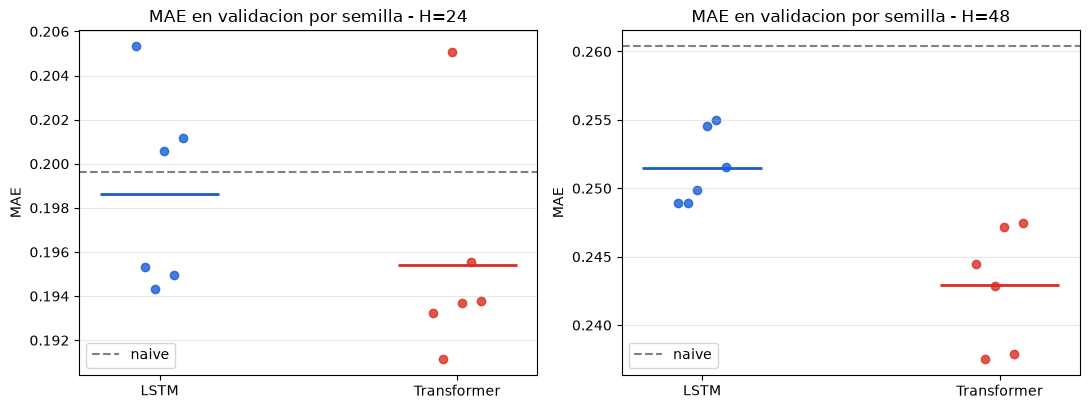

In [9]:
# Comparacion pareada por semilla: diferencia = MAE_Transformer - MAE_LSTM (negativo = gana Transformer)
print(f"{'semilla':>7} | {'LSTM 24':>8} {'Trf 24':>8} {'dif':>8} | {'LSTM 48':>8} {'Trf 48':>8} {'dif':>8}")
diffs = {24: [], 48: []}
for s in seeds:
    row = []
    for H in (24, 48):
        l = seed_res[("LSTM", H, s)]["mae"]
        t = seed_res[("Transformer", H, s)]["mae"]
        diffs[H].append(t - l)
        row += [l, t, t - l]
    print(f"{s:>7} | {row[0]:>8.4f} {row[1]:>8.4f} {row[2]:>+8.4f} | {row[3]:>8.4f} {row[4]:>8.4f} {row[5]:>+8.4f}")

for H in (24, 48):
    d = np.array(diffs[H])
    print(f"\nH={H}: Transformer gana en {(d < 0).sum()}/{len(d)} semillas; "
          f"diferencia media = {d.mean():+.4f} (std {d.std(ddof=1):.4f})")

# Visualizacion: MAE de cada semilla por modelo y horizonte
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)
for ax, H in zip(axes, (24, 48)):
    for j, (model_name, color) in enumerate([("LSTM", "#175CD3"), ("Transformer", "#D92D20")]):
        mae = np.array([seed_res[(model_name, H, s)]["mae"] for s in seeds])
        ax.scatter(np.full(len(mae), j) + np.linspace(-0.08, 0.08, len(mae)), mae, color=color, alpha=0.8)
        ax.hlines(mae.mean(), j - 0.2, j + 0.2, color=color, linewidth=2)
    ax.axhline(naive_mae if H == 24 else naive_mae_48, color="gray", linestyle="--", label="naive")
    ax.set(title=f"MAE en validacion por semilla - H={H}", xticks=[0, 1],
           xticklabels=["LSTM", "Transformer"], ylabel="MAE")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

### 4.2a - ¿Por qué el error aumenta de 24 h a 48 h?

**Respuesta:** Primero, los datos (MAE en validación):

| Modelo | $H=24$ | $H=48$ | Aumento |
|---|---|---|---|
| LSTM | 0.1959 | 0.2389 | +22% |
| Transformer | 0.1933 | 0.2475 | +28% |
| Naive | 0.1996 | 0.2604 | +30% |

**Idea general:** predecir más lejos siempre es más difícil, como con el pronóstico del clima: el de mañana es bastante confiable y el de dentro de una semana mucho menos.

**Caso iterativo (lo que plantea el enunciado para el LSTM).** Un modelo iterativo predice solo una hora adelante y usa esa predicción como si fuera un dato real para predecir la siguiente, y así sucesivamente. Cada paso comete un pequeño error y **hereda los errores de los pasos anteriores**, así que se van acumulando. Para una serie sencilla, donde cada valor depende del anterior con un factor $\phi$, la varianza del error después de $h$ pasos es:

$$\text{Var}(\text{error}_h) = \sigma^2\left(1 + \phi^2 + \phi^4 + \dots + \phi^{2(h-1)}\right)$$

Cada paso adicional **suma un término positivo**, así que el error solo puede crecer. Con 48 pasos se acumulan más términos que con 24.

*Nota importante:* en este laboratorio **ninguno de los dos modelos es iterativo**. Ambos, incluido el LSTM, predicen directamente el valor de dentro de $H$ horas en un solo paso. La explicación anterior describe lo que pasaría con un LSTM iterativo.

**Caso directo (lo que implementamos).** Aquí no hay acumulación, pero el error igual crece por una razón más básica: **entre más lejos está el futuro, menos información da el presente sobre él**. En 48 horas pasan más cosas que la ventana no puede anticipar (cambios de carga, clima, operación del transformador). Esto se ve en la ACF: el valor actual se parece en 0.925 al de dentro de 24 horas, pero solo en 0.876 al de dentro de 48.

Esa diferencia, que parece pequeña, tiene un efecto grande. El error del baseline naive (que asume que no hay cambio) sube de 0.150 a 0.249 en train, **un 65% más**, solo porque la correlación bajó de 0.925 a 0.876. Los modelos aprenden a corregir al naive, pero no pueden eliminar esa incertidumbre extra. Además, el cambio que tienen que predecir es más grande y variable a 48 horas: su dispersión pasa de 0.39 a 0.50.

### 4.2b - Transformer vs LSTM y flujo del gradiente

**Respuesta:** **Con una sola corrida la premisa no se observa, pero con varias semillas sí se cumple en lo esencial.**

- **Corrida única (tabla del 4.2):** el Transformer gana con 24 h y el LSTM con 48 h, lo contrario de la premisa.
- **Experimento con más semillas (6 semillas):**

| Horizonte | LSTM | Transformer | El Transformer gana en |
|---|---|---|---|
| 24 h | 0.1986 ± 0.0044 | 0.1954 ± 0.0049 | 4 de 6 semillas (empate) |
| 48 h | 0.2515 ± 0.0027 | **0.2429 ± 0.0044** | **6 de 6 semillas** |

Con 48 horas el Transformer gana siempre. Con 24 horas la diferencia es más pequeña que la variación entre semillas, así que los dos modelos están empatados. La corrida única del LSTM con 48 h (0.2389) fue atípica: está fuera del rango de las 6 semillas (0.2489 a 0.2550).

**¿Por qué pasa esto? El camino que recorre el gradiente.** Para aprender, el error de la predicción tiene que "viajar hacia atrás" hasta cada hora de la ventana e indicar cómo ajustar los pesos. La diferencia entre los dos modelos está en **qué tan largo es ese camino**.

- **En el LSTM** es como un teléfono descompuesto. La predicción sale solo del último estado, así que para que el error llegue a una hora de hace 72 horas debe pasar por los 72 pasos intermedios, uno por uno. En cada paso se multiplica por la compuerta de olvido $f$ (un valor menor que 1):

$$\frac{\partial \mathcal{L}}{\partial c_k} \approx \frac{\partial \mathcal{L}}{\partial c_T}\cdot f_{k+1}\cdot f_{k+2}\cdots f_T$$

  Multiplicar muchas veces por números menores que 1 da un número muy pequeño. La señal llega débil a las horas lejanas, y al modelo le cuesta aprender de ellas.

- **En el Transformer** es una llamada directa. La salida es un promedio ponderado de todas las horas de la ventana, así que el error llega a cada hora **en un solo salto**, sin pasar por intermediarios:

$$\frac{\partial z_0}{\partial v_s} = \alpha_{0s}$$

  La fuerza de la señal depende solo del peso de atención $\alpha_{0s}$ de esa hora, no de qué tan lejos esté.

**¿Por qué la ventaja aparece con 48 h y no con 24 h?**
- **Con 48 horas**, la información útil está lejos: según los mapas, el modelo mira sobre todo las horas de hace 46-51 y 72-74. Para el LSTM eso es un camino largo por el teléfono descompuesto; para el Transformer es la misma llamada directa de siempre.
- **Con 24 horas** también sirven momentos más cercanos (hace 23-26 horas), y el valor más reciente ya entra directamente en la predicción. La desventaja del LSTM pesa menos y quedan empatados.
- **El LSTM no pierde por mucho**, porque su celda de memoria está diseñada justo para mitigar este problema: si la compuerta de olvido se mantiene cerca de 1, la señal casi no se debilita. Por eso la ventaja del Transformer es moderada (~3.4% de MAE) y no enorme.

**Lección:** cuando las diferencias entre modelos son de 1-4%, una sola corrida puede llevar a la conclusión contraria. Aquí la corrida única decía lo opuesto de lo que muestran 6 semillas.

## Registro de uso limitado de IA generativa

### Prompt 1 — Estructura y código de los notebooks

**Prompt utilizado:** "¿Puedes hacer los notebooks con la estructura de código que se pide en ellos? Aún sin responder, pero con el código que se pide, para ya tener un orden de estos."

**Por qué funcionó:**

- **Limitó el alcance:** se pidió solo el código que exige el PDF, dejando las preguntas de análisis sin responder. La respuesta se enfocó en implementar lo solicitado sin mezclarlo con la interpretación de resultados.
- **Usó el PDF como referencia:** los esqueletos, docstrings y celdas de verificación se tomaron directamente del documento del laboratorio.
- **Pidió orden:** un notebook por task, cada uno autocontenido, lo que facilita revisar cada entrega por separado.


### Prompt 2 — Experimento con más semillas

**Prompts utilizados:**

1. "¿Puedes, en un playground, correr con diferentes semillas y ver si hay alguna que cumpla con la teoría?"

**Por qué funcionó:** en lugar de escoger una semilla que confirmara la teoría (lo que sería seleccionar resultados a conveniencia), se repitió el entrenamiento con 6 semillas y se reportó la media y la desviación estándar. El experimento fija el determinismo, así que es reproducible. Además está separado del pipeline principal, por lo que no altera las verificaciones oficiales. Con esa evidencia se actualizó la respuesta del 4.2b.